# Striker Era Adjustment: Dataset Audit & Exploratory Analysis

**Prepared for:** Prof. Daniel Eck, UIUC Department of Statistics

**Purpose:** This notebook documents the full picture of the dataset
assembled for the Full House Model extension to top-5 European football
leagues. Every finding here — positive or negative — is stated plainly.
The goal is to give you an honest baseline before any modeling decisions
are made.

**Data source:** FBref Big 5 European Leagues combined stats pages,
manually exported as HTML and parsed locally.

**Coverage window:** 1997-98 through 2022-23 (26 seasons).
Note: 1995-96 and 1996-97 failed to parse due to a different HTML table
structure on FBref for those seasons — they are absent from this dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Styling ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        130,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linewidth':    0.6,
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
PALETTE = ['#2563EB','#DC2626','#16A34A','#D97706','#7C3AED']

# ── Load data ─────────────────────────────────────────────────────────────────
DATA_PATH = '/Users/muhammadhamza/striker_era_ranking/data/raw/fbref/all_seasons_combined.csv'
df = pd.read_csv(DATA_PATH)

# Standardise league names (historical aliases)
df['league'] = df['league'].replace({
    'Division 1':    'Ligue 1',
    'First Division': 'Premier League',
})

# Ordered league list used throughout
LEAGUES = ['Premier League', 'La Liga', 'Serie A', 'Bundesliga', 'Ligue 1']
LEAGUE_COLORS = dict(zip(LEAGUES, PALETTE))

print(f"Loaded {len(df):,} rows × {len(df.columns)} columns")
print(f"Seasons: {df['season'].nunique()} ({df['season'].min()} → {df['season'].max()})")
print(f"Leagues: {sorted(df['league'].unique())}")
print(f"\nColumn types:\n{df.dtypes}")

Loaded 69,330 rows × 13 columns
Seasons: 26 (1997-1998 → 2022-2023)
Leagues: ['Bundesliga', 'La Liga', 'Ligue 1', 'Premier League', 'Serie A']

Column types:
player               object
nationality          object
position             object
team                 object
league               object
age                 float64
matches               int64
minutes               int64
goals                 int64
assists               int64
season               object
assists_recorded       bool
ga_per_90           float64
dtype: object


---
## 1. Dataset Overview

High-level shape of what we have before any filtering.

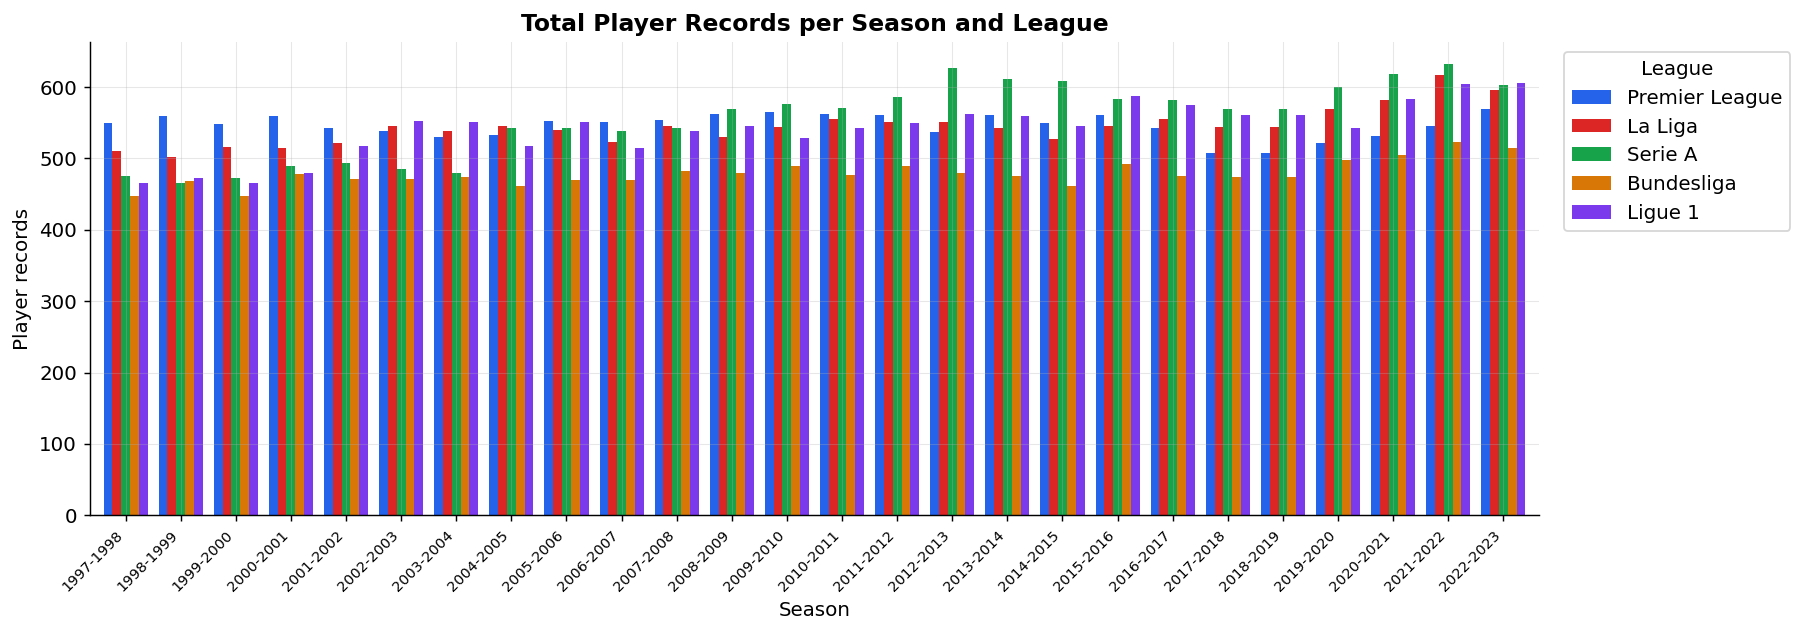


Row counts by league (all seasons combined):
league
Serie A           14433
Premier League    14207
La Liga           14158
Ligue 1           14082
Bundesliga        12450


In [2]:
# ── 1a. Season × league row counts ───────────────────────────────────────────
pivot = (df.groupby(['season','league'])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=LEAGUES))

fig, ax = plt.subplots(figsize=(14, 5))
pivot.plot(kind='bar', ax=ax, color=PALETTE, width=0.8)
ax.set_title('Total Player Records per Season and League')
ax.set_xlabel('Season')
ax.set_ylabel('Player records')
ax.set_xticklabels(pivot.index, rotation=45, ha='right', fontsize=8)
ax.legend(title='League', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig01_records_per_season_league.png', bbox_inches='tight')
plt.show()

print("\nRow counts by league (all seasons combined):")
print(df['league'].value_counts().to_string())

**Observation:** Record counts are broadly stable across seasons (~2,500-2,900
rows per season), reflecting consistent squad sizes across the five leagues.
The upward drift in recent seasons reflects expanded squad registration rules
and FBref's improving historical coverage.

In [3]:
# ── 1b. Missing seasons ───────────────────────────────────────────────────────
all_expected = [f"{y}-{y+1}" for y in range(1995, 2023)]
present      = set(df['season'].unique())
missing      = [s for s in all_expected if s not in present]

print("=== MISSING SEASONS ===")
print(f"Expected: {len(all_expected)} seasons (1995-96 → 2022-23)")
print(f"Present : {len(present)} seasons")
print(f"Missing : {missing}")
print()
print("Root cause: FBref's 1995-96 and 1996-97 Big 5 combined pages use a")
print("different HTML table structure (no id='stats_standard'). These two")
print("seasons require a separate parsing strategy or manual reconstruction.")

=== MISSING SEASONS ===
Expected: 28 seasons (1995-96 → 2022-23)
Present : 26 seasons
Missing : ['1995-1996', '1996-1997']

Root cause: FBref's 1995-96 and 1996-97 Big 5 combined pages use a
different HTML table structure (no id='stats_standard'). These two
seasons require a separate parsing strategy or manual reconstruction.


---
## 2. Position Distribution and Forward Definition

The Full House Model will be applied to **forwards only**.
We need to understand FBref's position taxonomy before deciding
which position codes qualify.

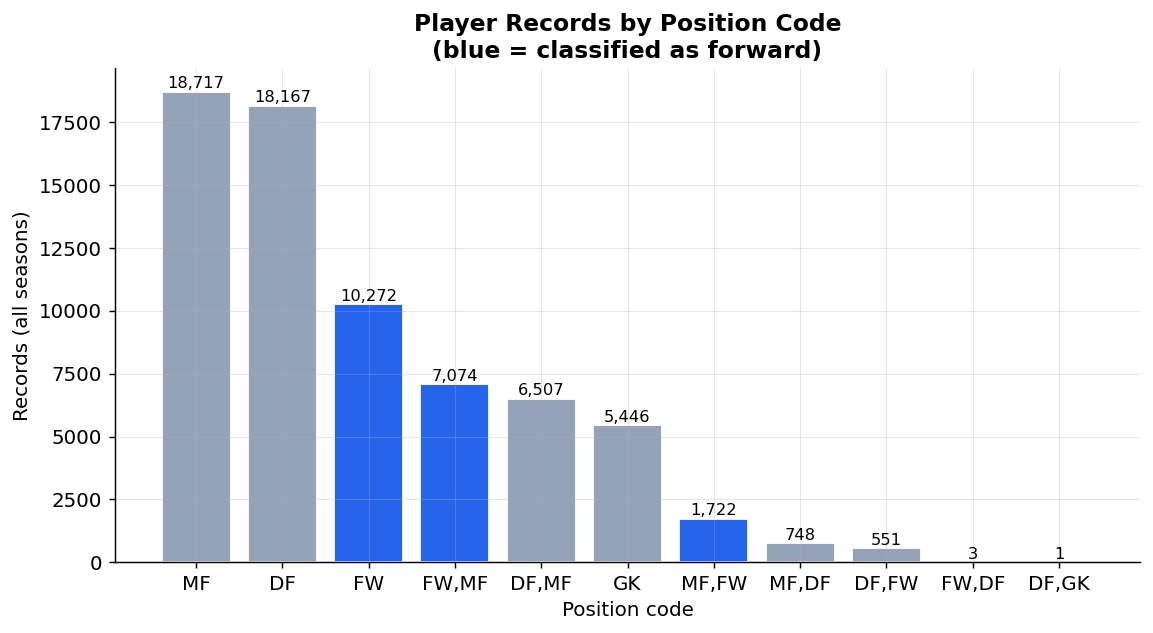


Forward position codes included: ['FW', 'FW,MF', 'MF,FW', 'FW,DF']
Forward records (all seasons): 19,071
Non-forward records excluded : 50,259

Note: 'MF,FW' and 'FW,MF' are treated identically —
FBref lists the primary position first, but both codes indicate
a player who regularly operates as a forward.


In [4]:
pos_counts = df['position'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2563EB' if p in ['FW','FW,MF','MF,FW','FW,DF'] else '#94A3B8'
          for p in pos_counts.index]
bars = ax.bar(pos_counts.index, pos_counts.values, color=colors, edgecolor='white')
ax.set_title('Player Records by Position Code\n(blue = classified as forward)')
ax.set_xlabel('Position code')
ax.set_ylabel('Records (all seasons)')
for bar, val in zip(bars, pos_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('fig02_position_distribution.png', bbox_inches='tight')
plt.show()

# Forward definition
FW_POSITIONS = ['FW', 'FW,MF', 'MF,FW', 'FW,DF']
fwd = df[df['position'].isin(FW_POSITIONS)].copy()

print(f"\nForward position codes included: {FW_POSITIONS}")
print(f"Forward records (all seasons): {len(fwd):,}")
print(f"Non-forward records excluded : {len(df) - len(fwd):,}")
print(f"\nNote: 'MF,FW' and 'FW,MF' are treated identically —")
print("FBref lists the primary position first, but both codes indicate")
print("a player who regularly operates as a forward.")

**Decision point for Prof. Eck:** Should `MF,FW` (midfielder who also plays
forward) be included? Including it adds ~20% more players per season
and captures players like Firmino, Griezmann, and Müller who are
functionally forwards. Excluding it keeps the sample cleaner but risks
omitting key era-defining players. The analysis below includes them.

In [5]:
# ── Position breakdown by league ─────────────────────────────────────────────
pos_league = (df[df['position'].isin(FW_POSITIONS)]
              .groupby(['league','position'])
              .size()
              .unstack(fill_value=0)
              .reindex(index=LEAGUES, columns=FW_POSITIONS, fill_value=0))

print("\nForward records by league and position code:")
print(pos_league.to_string())


Forward records by league and position code:
position          FW  FW,MF  MF,FW  FW,DF
league                                   
Premier League  2163   1532    330      0
La Liga         2003   1451    317      0
Serie A         2328   1100    266      1
Bundesliga      1767   1330    358      1
Ligue 1         2011   1661    451      1


---
## 3. The 900-Minute Threshold

Following Eck et al. (2024), we apply a minimum minutes threshold
to define "full-time" forwards. The paper uses plate appearances
for batters; we use minutes played.

**Proposed threshold: 900 minutes** (~10 full matches).
This is the minimum for qualifying for official FBref rate stats.

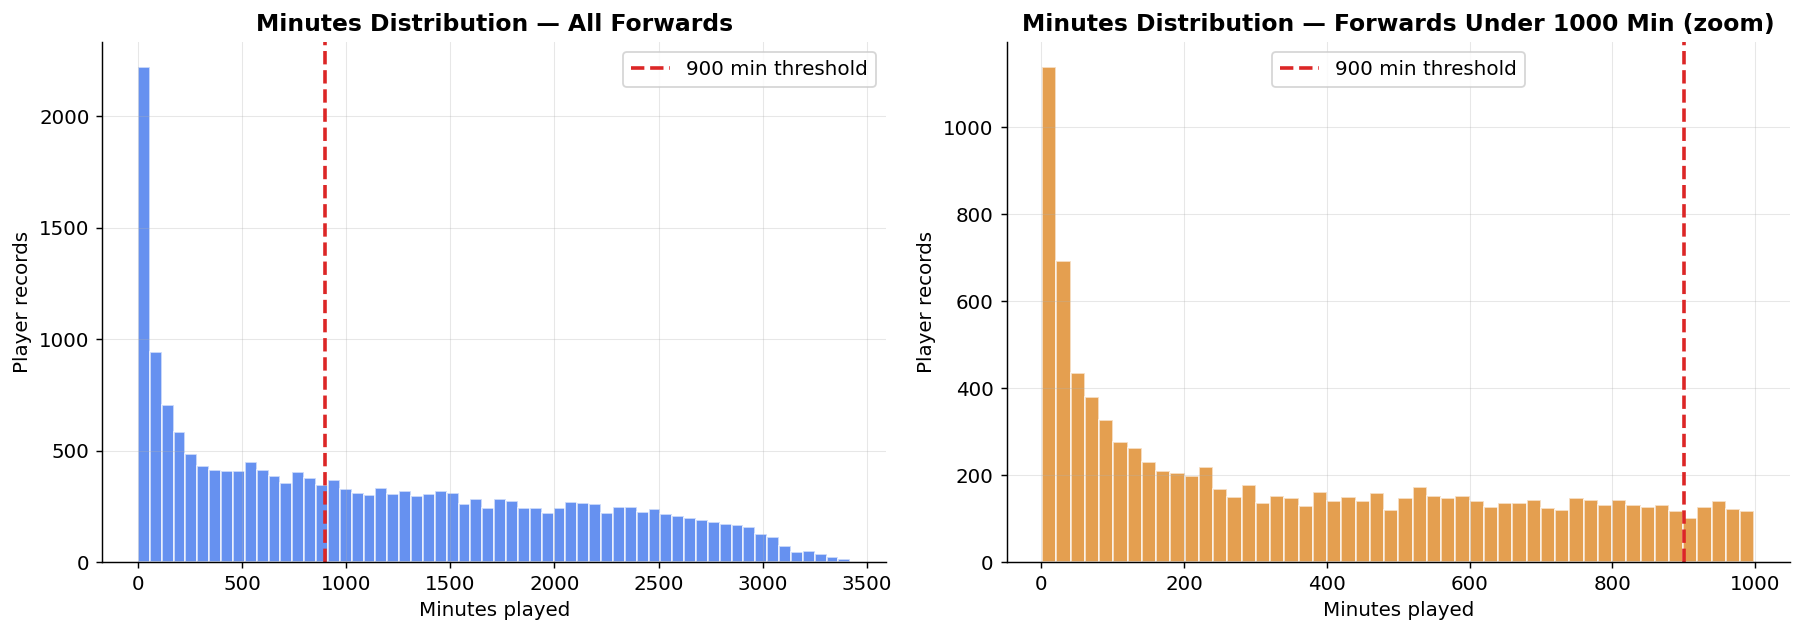

All forward records       : 19,071
Below 900 min (excluded) : 9,269  (48.6%)
At or above 900 min      : 9,802  (51.4%)


In [6]:
MIN_MINUTES = 900

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All forwards — minutes distribution
axes[0].hist(fwd['minutes'], bins=60, color='#2563EB', alpha=0.7, edgecolor='white')
axes[0].axvline(MIN_MINUTES, color='#DC2626', linewidth=2,
                linestyle='--', label=f'{MIN_MINUTES} min threshold')
axes[0].set_title('Minutes Distribution — All Forwards')
axes[0].set_xlabel('Minutes played')
axes[0].set_ylabel('Player records')
axes[0].legend()

# Zoom: 0–1000 minutes to see the tail
axes[1].hist(fwd[fwd['minutes'] < 1000]['minutes'], bins=50,
             color='#D97706', alpha=0.7, edgecolor='white')
axes[1].axvline(MIN_MINUTES, color='#DC2626', linewidth=2,
                linestyle='--', label=f'{MIN_MINUTES} min threshold')
axes[1].set_title('Minutes Distribution — Forwards Under 1000 Min (zoom)')
axes[1].set_xlabel('Minutes played')
axes[1].set_ylabel('Player records')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig03_minutes_distribution.png', bbox_inches='tight')
plt.show()

qf = fwd[fwd['minutes'] >= MIN_MINUTES].copy()

print(f"All forward records       : {len(fwd):,}")
print(f"Below {MIN_MINUTES} min (excluded) : {len(fwd[fwd['minutes'] < MIN_MINUTES]):,}  "
      f"({len(fwd[fwd['minutes'] < MIN_MINUTES])/len(fwd)*100:.1f}%)")
print(f"At or above {MIN_MINUTES} min      : {len(qf):,}  "
      f"({len(qf)/len(fwd)*100:.1f}%)")

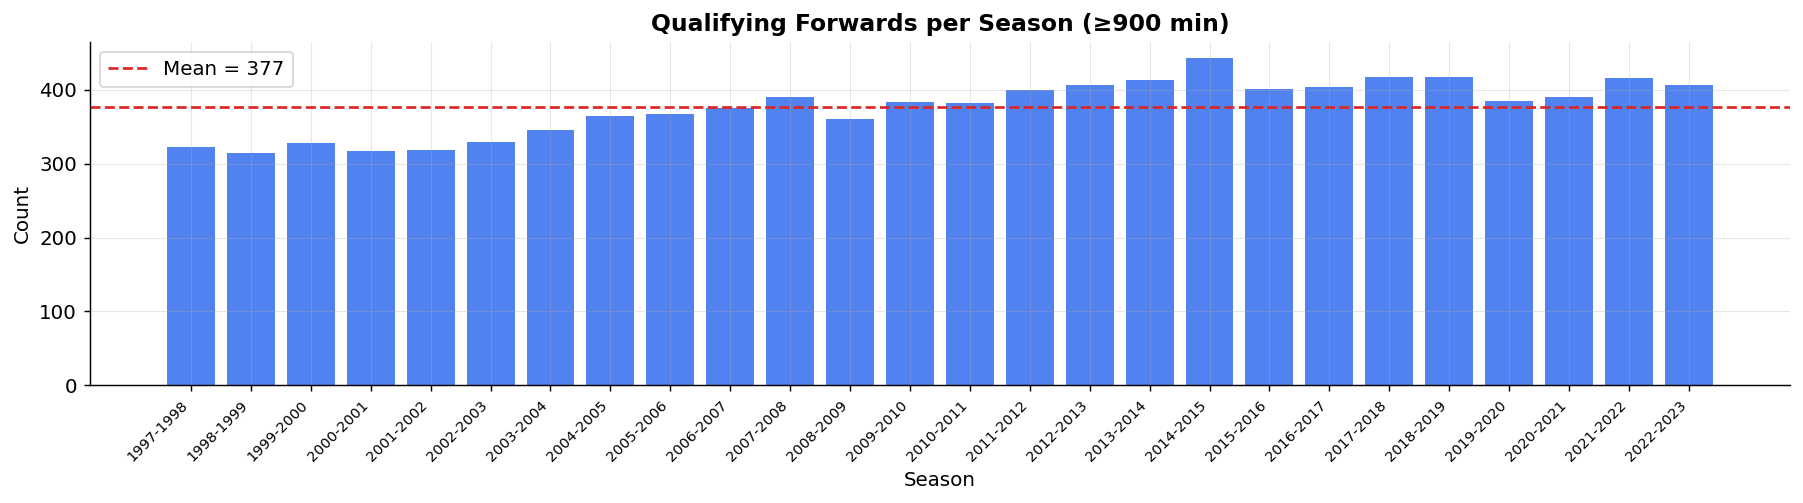


Qualifying forwards per season:
count     26.0
mean     377.0
std       37.0
min      315.0
25%      349.8
50%      384.5
75%      405.5
max      443.0

By league (across all seasons):
league
Premier League    2128
La Liga           2075
Serie A           1826
Bundesliga        1759
Ligue 1           2014


In [7]:
# Qualifying forwards per season
qf_per_season = qf.groupby('season').size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(qf_per_season.index, qf_per_season.values, color='#2563EB', alpha=0.8)
ax.axhline(qf_per_season.mean(), color='#DC2626', linestyle='--',
           linewidth=1.5, label=f'Mean = {qf_per_season.mean():.0f}')
ax.set_title(f'Qualifying Forwards per Season (≥{MIN_MINUTES} min)')
ax.set_xlabel('Season')
ax.set_ylabel('Count')
ax.set_xticklabels(qf_per_season.index, rotation=45, ha='right', fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig('fig04_qualifying_forwards_per_season.png', bbox_inches='tight')
plt.show()

print("\nQualifying forwards per season:")
print(qf_per_season.describe().round(1).to_string())
print("\nBy league (across all seasons):")
print(qf.groupby('league').size().reindex(LEAGUES).to_string())

**Key finding:** With the 900-minute threshold, we have roughly
**15–25 qualifying forwards per league per season** — significantly
fewer than the ~100 full-time batters Eck et al. work with in baseball.
This small-n problem directly affects the stability of the interpolated CDF
and the Scholz tail extrapolation. It is the most important structural
difference between this application and the original paper.

---
## 4. Multi-Club Players: The Double-Counting Problem

FBref records a player once per club when they transfer mid-season,
plus a combined "2 Clubs" row. Our parser did not filter out individual
club rows for mid-season transfers, so some players appear twice.

In [8]:
# Detect duplicates within a season
dup_check = (qf.groupby(['player','season'])
               .size()
               .reset_index(name='n_rows')
               .query('n_rows > 1'))

print(f"Qualifying forwards appearing more than once in a season: {len(dup_check)}")
print("\nSample duplicate cases:")
if len(dup_check) > 0:
    sample_players = dup_check['player'].head(5).tolist()
    print(qf[qf['player'].isin(sample_players)]
          [['season','player','team','minutes','goals','assists']]
          .sort_values(['player','season'])
          .to_string(index=False))

print("""
Issue: If a player moved clubs mid-season, they appear as two separate
rows with partial minutes each. Summing both rows double-counts them
as two distinct players and splits their stats across two teams.

Fix required before modeling:
  For players with two rows in the same season, collapse to a single
  row by summing minutes, goals, and assists. Use the team with more
  minutes as the 'primary' team.
""")

Qualifying forwards appearing more than once in a season: 74

Sample duplicate cases:
   season              player          team  minutes  goals  assists
2014-2015        Adama Traoré         Lille     1044      2        0
2016-2017        Adama Traoré Middlesbrough     1541      0        1
2017-2018        Adama Traoré        Wolves      902      1        1
2018-2019        Adama Traoré        Wolves      902      1        1
2019-2020        Adama Traoré          Metz     1007      1        4
2019-2020        Adama Traoré        Wolves     2605      4        9
2020-2021        Adama Traoré        Wolves     2649      2        2
2021-2022        Adama Traoré        Wolves     1067      1        0
2022-2023        Adama Traoré        Wolves     1496      2        1
2017-2018    Adrien Thomasson    Strasbourg     2479      5        8
2018-2019    Adrien Thomasson    Strasbourg     2479      5        8
2019-2020    Adrien Thomasson    Strasbourg     2072      8        1
2020-2021    Adri

---
## 5. Assists Coverage: The Core Data Quality Issue

Assists were not systematically tracked in all leagues before the
late 1990s. FBref's historical reconstruction is incomplete for
early seasons, particularly for non-EPL leagues.

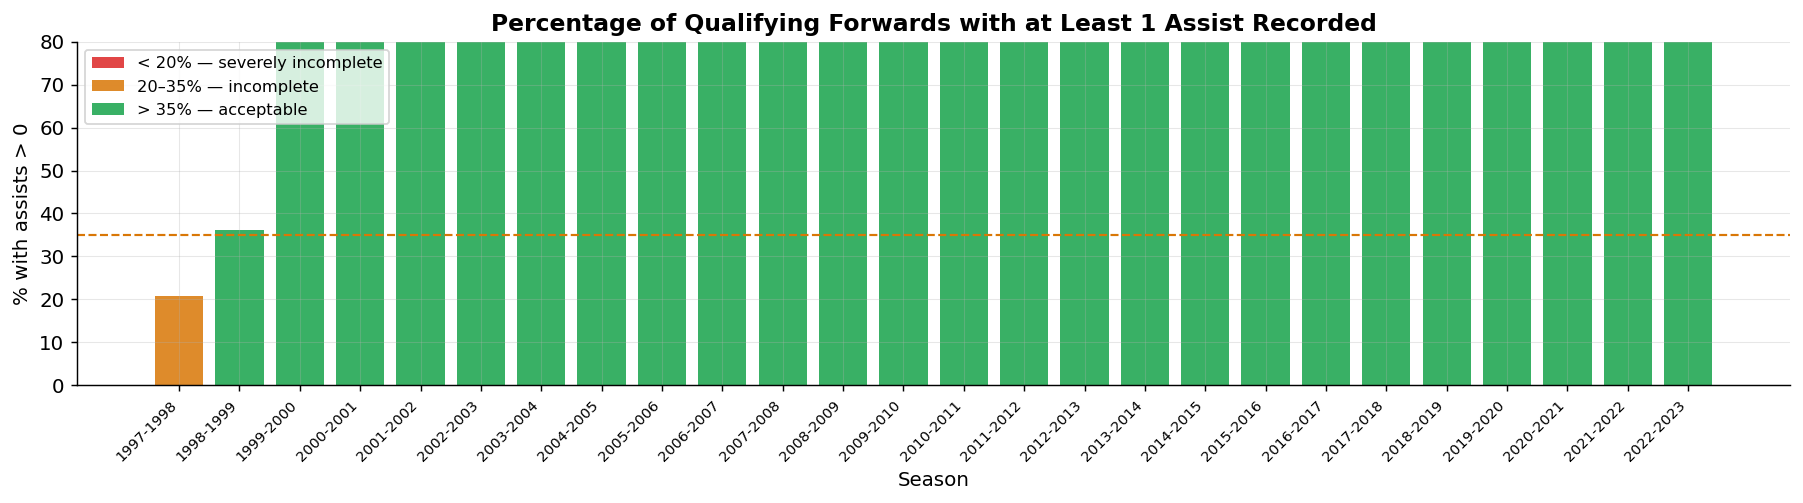

Assists coverage by season (qualified forwards):
           total  with_asst  pct_with_asst  mean_asst
season                                               
1997-1998    323         67           20.7   0.795666
1998-1999    315        114           36.2   1.355556
1999-2000    328        297           90.5   3.277439
2000-2001    317        285           89.9   2.940063
2001-2002    319        272           85.3   2.843260
2002-2003    330        296           89.7   3.166667
2003-2004    346        309           89.3   3.184971
2004-2005    365        323           88.5   3.101370
2005-2006    367        318           86.6   2.942779
2006-2007    376        316           84.0   2.720745
2007-2008    390        322           82.6   2.674359
2008-2009    361        316           87.5   2.944598
2009-2010    384        339           88.3   2.846354
2010-2011    382        337           88.2   3.130890
2011-2012    400        359           89.8   3.247500
2012-2013    406        355      

In [9]:
# Assists coverage by season (qualified forwards only)
assist_audit = qf.groupby('season').agg(
    total     = ('player', 'count'),
    with_asst = ('assists', lambda x: (x > 0).sum()),
    mean_asst = ('assists', 'mean'),
    zero_asst = ('assists', lambda x: (x == 0).sum()),
).copy()
assist_audit['pct_with_asst'] = (
    assist_audit['with_asst'] / assist_audit['total'] * 100
).round(1)

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#DC2626' if p < 20 else '#D97706' if p < 35 else '#16A34A'
          for p in assist_audit['pct_with_asst']]
bars = ax.bar(assist_audit.index, assist_audit['pct_with_asst'],
              color=colors, alpha=0.85)
ax.axhline(35, color='#D97706', linestyle='--', linewidth=1.2,
           label='35% threshold (caution zone)')
ax.set_title('Percentage of Qualifying Forwards with at Least 1 Assist Recorded')
ax.set_xlabel('Season')
ax.set_ylabel('% with assists > 0')
ax.set_ylim(0, 80)
ax.set_xticklabels(assist_audit.index, rotation=45, ha='right', fontsize=8)
ax.legend()

# Colour legend
from matplotlib.patches import Patch  # noqa: E402
legend_elements = [
    Patch(facecolor='#DC2626', alpha=0.85, label='< 20% — severely incomplete'),
    Patch(facecolor='#D97706', alpha=0.85, label='20–35% — incomplete'),
    Patch(facecolor='#16A34A', alpha=0.85, label='> 35% — acceptable'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('fig05_assists_coverage.png', bbox_inches='tight')
plt.show()

print("Assists coverage by season (qualified forwards):")
print(assist_audit[['total','with_asst','pct_with_asst','mean_asst']].to_string())

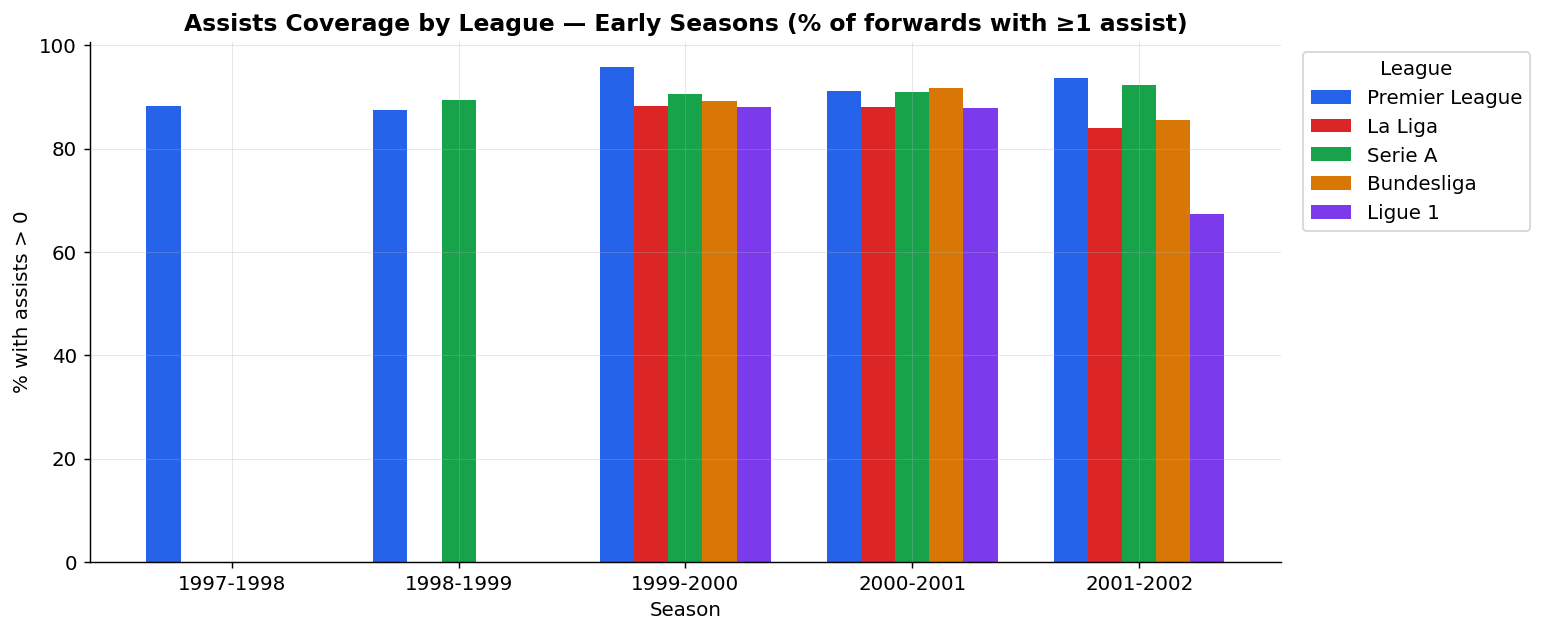


Assists coverage by league in early seasons:
league     Premier League  La Liga  Serie A  Bundesliga  Ligue 1
season                                                          
1997-1998            88.2      0.0      0.0         0.0      0.0
1998-1999            87.5      0.0     89.5         0.0      0.0
1999-2000            95.9     88.3     90.6        89.2     88.1
2000-2001            91.2     88.0     90.9        91.8     87.9
2001-2002            93.6     84.0     92.3        85.5     67.3


In [10]:
# Assists coverage by league — early seasons only
early = qf[qf['season'].isin(['1997-1998','1998-1999','1999-2000',
                               '2000-2001','2001-2002'])].copy()

asst_by_league = early.groupby(['season','league']).agg(
    players  = ('player', 'count'),
    with_asst = ('assists', lambda x: (x > 0).sum()),
).reset_index()
asst_by_league['pct'] = (
    asst_by_league['with_asst'] / asst_by_league['players'] * 100
).round(1)

pivot_asst = asst_by_league.pivot(index='season', columns='league',
                                   values='pct').reindex(columns=LEAGUES)

fig, ax = plt.subplots(figsize=(12, 5))
pivot_asst.plot(kind='bar', ax=ax, color=PALETTE, width=0.75)
ax.set_title('Assists Coverage by League — Early Seasons (% of forwards with ≥1 assist)')
ax.set_xlabel('Season')
ax.set_ylabel('% with assists > 0')
ax.set_xticklabels(pivot_asst.index, rotation=0)
ax.legend(title='League', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig06_assists_coverage_by_league_early.png', bbox_inches='tight')
plt.show()

print("\nAssists coverage by league in early seasons:")
print(pivot_asst.fillna(0).round(1).to_string())

**Critical finding:** The 1997-98 and 1998-99 seasons have severely
incomplete assist data — under 20% of qualifying forwards have any
assists recorded. The problem is concentrated in La Liga, Serie A,
Bundesliga, and Ligue 1. The Premier League has reasonable assist
coverage throughout.

**Methodological consequence:** For seasons before ~2000, using G+A
as the metric will systematically understate contributions for
non-EPL players (their assists are missing, not zero). Two options:

1. **Use goals only** for pre-2000 seasons across all leagues.
2. **Use G+A from 2000 onwards** and goals only for 1997-1999.

This is a modeling decision that should be made explicitly.

---
## 6. G+A per 90 Distribution for Qualifying Forwards

Distribution of the core metric across all seasons and leagues.

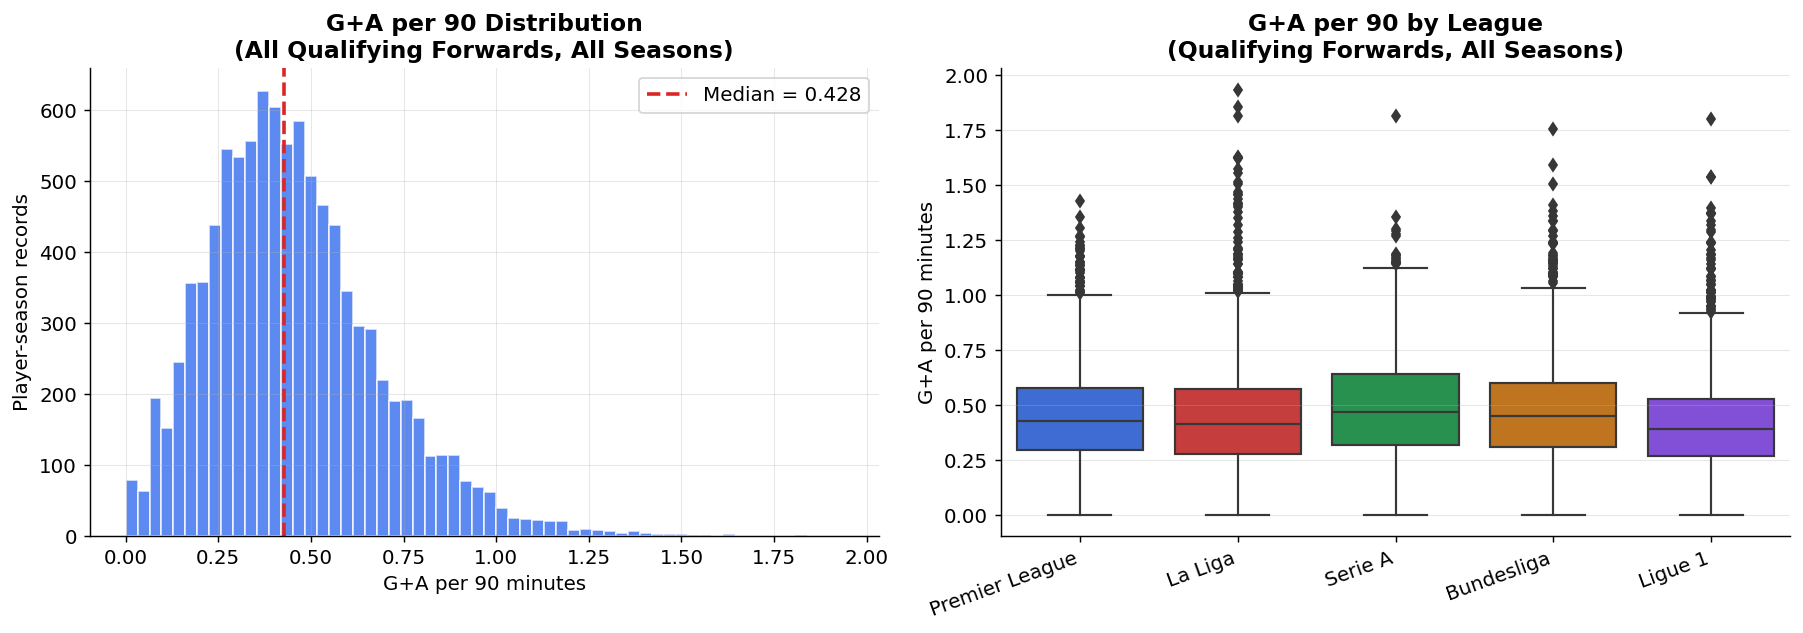

G+A per 90 summary (qualified forwards, all seasons):
count    9802.0000
mean        0.4576
std         0.2361
min         0.0000
25%         0.2912
50%         0.4280
75%         0.5843
max         1.9358

By league:
                 count    mean     std  min     25%     50%     75%     max
league                                                                     
Premier League  2128.0  0.4538  0.2273  0.0  0.2961  0.4276  0.5801  1.4301
La Liga         2075.0  0.4504  0.2507  0.0  0.2800  0.4134  0.5722  1.9358
Serie A         1826.0  0.4928  0.2359  0.0  0.3173  0.4698  0.6409  1.8175
Bundesliga      1759.0  0.4781  0.2413  0.0  0.3078  0.4529  0.6022  1.7575
Ligue 1         2014.0  0.4190  0.2183  0.0  0.2687  0.3909  0.5299  1.8007


In [11]:
# Recompute ga_per_90 cleanly on qualified forwards
qf = qf.copy()
qf['ga_per_90'] = ((qf['goals'] + qf['assists']) /
                   (qf['minutes'] / 90)).round(4)

# Remove inf values (shouldn't exist but be safe)
qf = qf[np.isfinite(qf['ga_per_90'])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
axes[0].hist(qf['ga_per_90'], bins=60, color='#2563EB', alpha=0.75,
             edgecolor='white')
axes[0].axvline(qf['ga_per_90'].median(), color='#DC2626',
                linewidth=2, linestyle='--',
                label=f"Median = {qf['ga_per_90'].median():.3f}")
axes[0].set_title('G+A per 90 Distribution\n(All Qualifying Forwards, All Seasons)')
axes[0].set_xlabel('G+A per 90 minutes')
axes[0].set_ylabel('Player-season records')
axes[0].legend()

# By league — box plots
league_order = LEAGUES
qf_plot = qf[qf['league'].isin(LEAGUES)]
sns.boxplot(data=qf_plot, x='league', y='ga_per_90', order=league_order,
            palette=PALETTE, ax=axes[1], linewidth=1.2)
axes[1].set_title('G+A per 90 by League\n(Qualifying Forwards, All Seasons)')
axes[1].set_xlabel('')
axes[1].set_ylabel('G+A per 90 minutes')
axes[1].set_xticklabels(league_order, rotation=20, ha='right')

plt.tight_layout()
plt.savefig('fig07_ga90_distribution.png', bbox_inches='tight')
plt.show()

print("G+A per 90 summary (qualified forwards, all seasons):")
print(qf['ga_per_90'].describe().round(4).to_string())

print("\nBy league:")
print(qf.groupby('league')['ga_per_90']
        .describe()
        .reindex(LEAGUES)
        .round(4)
        .to_string())

In [12]:
# Top 20 single-season G+A per 90 performances
print("Top 20 single-season G+A per 90 (qualifying forwards):")
top20 = (qf.nlargest(20, 'ga_per_90')
           [['season','player','league','team','goals','assists',
             'minutes','ga_per_90']])
print(top20.to_string(index=False))

Top 20 single-season G+A per 90 (qualifying forwards):
   season             player     league                team  goals  assists  minutes  ga_per_90
2012-2013       Lionel Messi    La Liga           Barcelona     46       11     2650     1.9358
2014-2015  Cristiano Ronaldo    La Liga         Real Madrid     48       16     3100     1.8581
2020-2021        Luis Muriel    Serie A            Atalanta     22        7     1436     1.8175
2011-2012       Lionel Messi    La Liga           Barcelona     50       16     3270     1.8165
2015-2016 Zlatan Ibrahimović    Ligue 1 Paris Saint-Germain     38       13     2549     1.8007
2020-2021 Robert Lewandowski Bundesliga       Bayern Munich     41        7     2458     1.7575
2015-2016        Luis Suárez    La Liga           Barcelona     40       17     3150     1.6286
2014-2015       Lionel Messi    La Liga           Barcelona     43       18     3375     1.6267
2017-2018       Lionel Messi    La Liga           Barcelona     36       13     2

---
## 7. Goals and Assists Trends Over Time

How has offensive output evolved across eras?
This is directly relevant to the Full House Model — era-adjustment
is only meaningful if there are real cross-era differences to correct for.

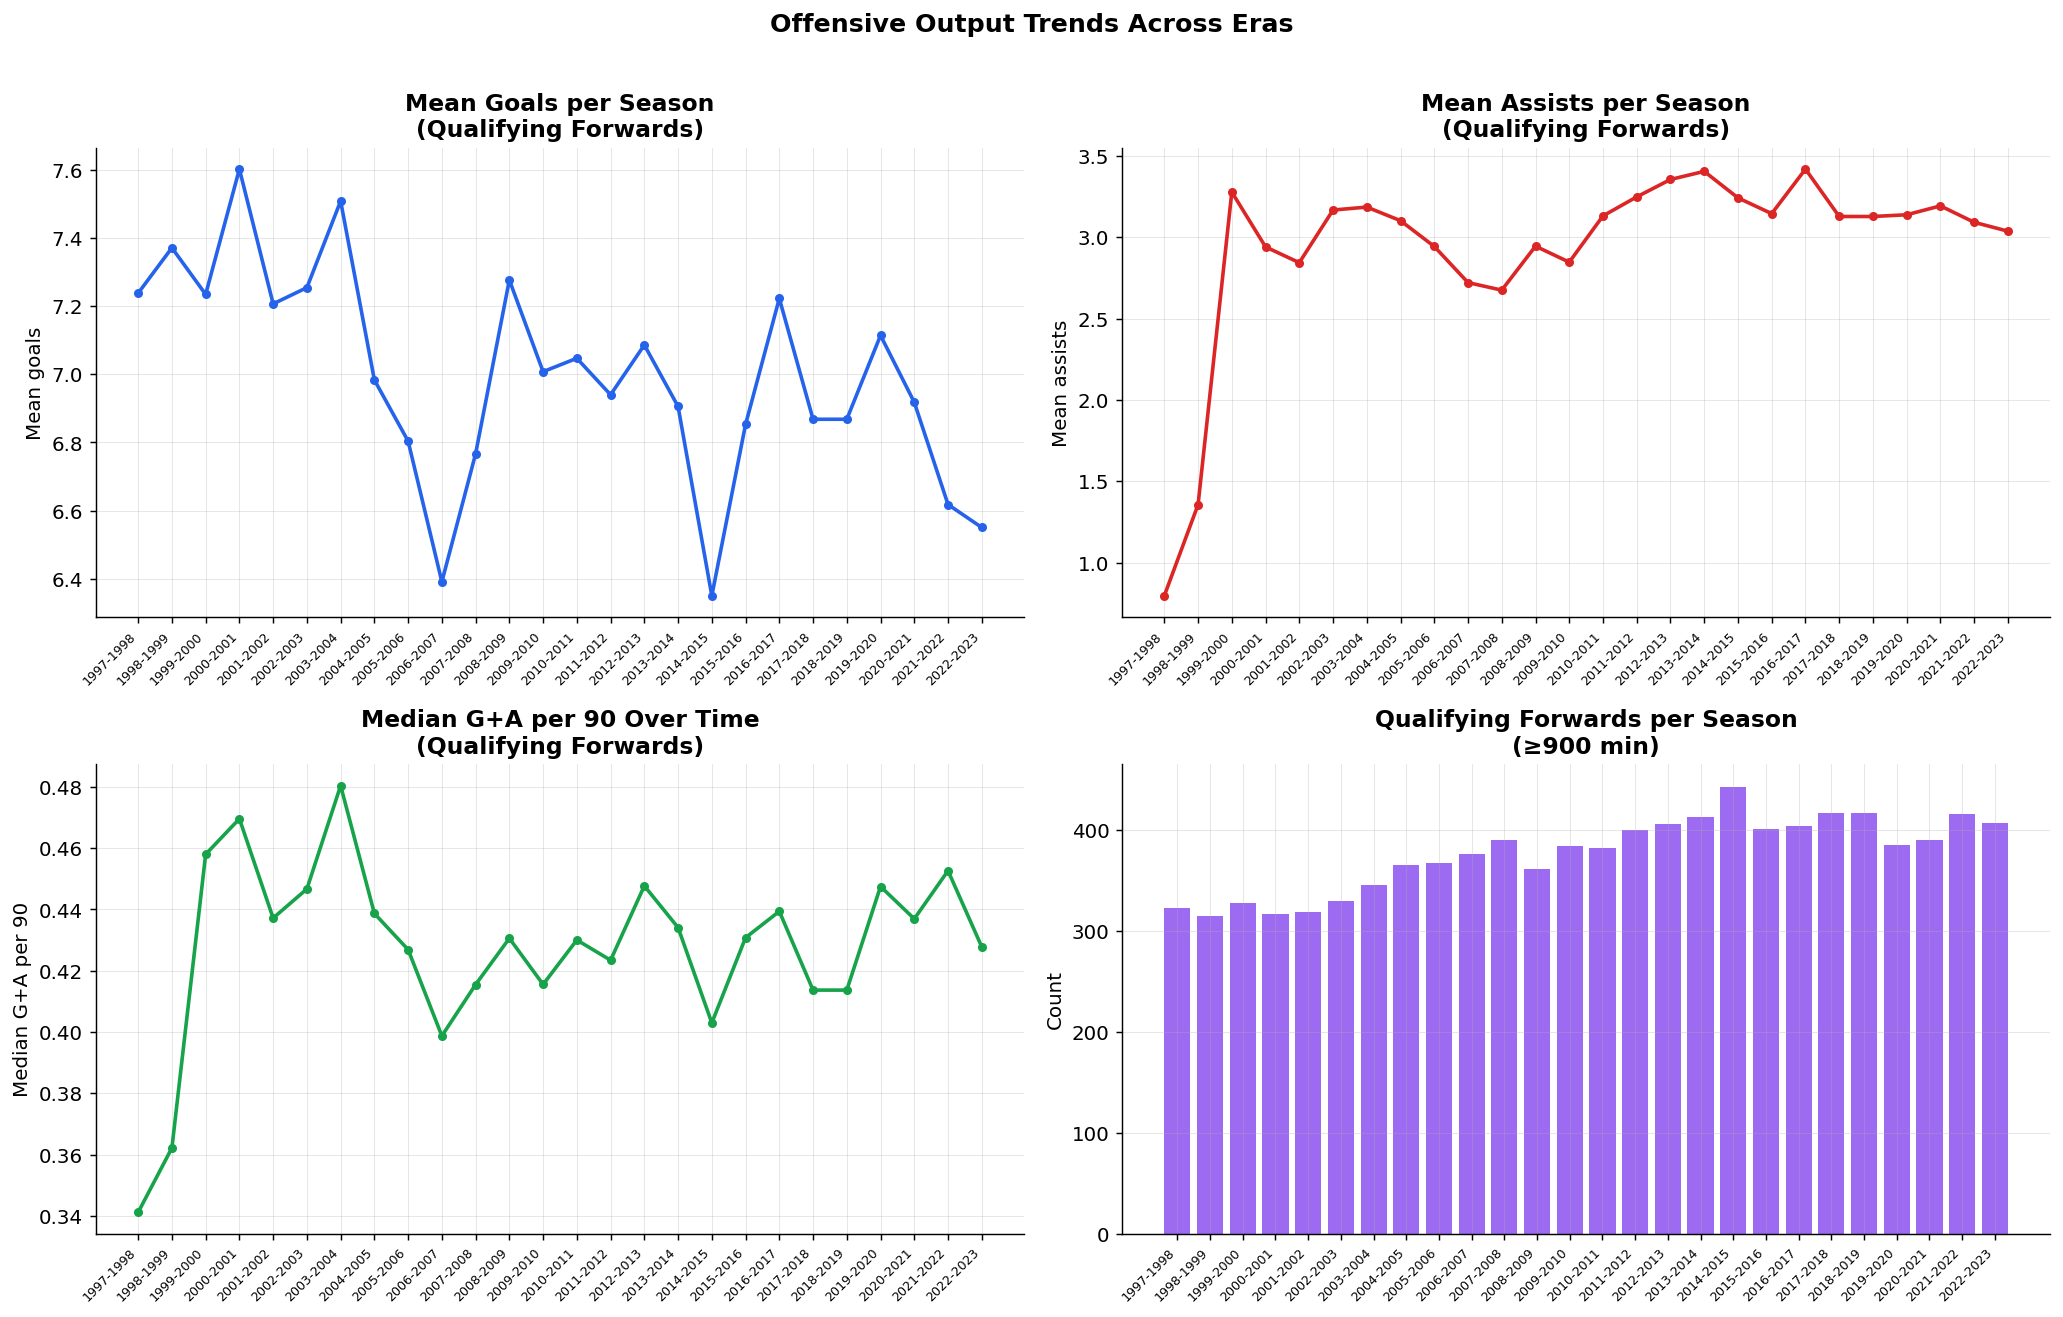

In [13]:
season_stats = qf.groupby('season').agg(
    mean_goals     = ('goals',    'mean'),
    mean_assists   = ('assists',  'mean'),
    mean_ga_per_90 = ('ga_per_90','mean'),
    median_ga_90   = ('ga_per_90','median'),
    n_forwards     = ('player',  'count'),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Mean goals per season
axes[0,0].plot(season_stats['season'], season_stats['mean_goals'],
               marker='o', markersize=4, color='#2563EB', linewidth=2)
axes[0,0].set_title('Mean Goals per Season\n(Qualifying Forwards)')
axes[0,0].set_xticklabels(season_stats['season'], rotation=45, ha='right', fontsize=7)
axes[0,0].set_xlabel(''); axes[0,0].set_ylabel('Mean goals')

# Mean assists per season
axes[0,1].plot(season_stats['season'], season_stats['mean_assists'],
               marker='o', markersize=4, color='#DC2626', linewidth=2)
axes[0,1].set_title('Mean Assists per Season\n(Qualifying Forwards)')
axes[0,1].set_xticklabels(season_stats['season'], rotation=45, ha='right', fontsize=7)
axes[0,1].set_xlabel(''); axes[0,1].set_ylabel('Mean assists')

# Median G+A per 90
axes[1,0].plot(season_stats['season'], season_stats['median_ga_90'],
               marker='o', markersize=4, color='#16A34A', linewidth=2)
axes[1,0].set_title('Median G+A per 90 Over Time\n(Qualifying Forwards)')
axes[1,0].set_xticklabels(season_stats['season'], rotation=45, ha='right', fontsize=7)
axes[1,0].set_xlabel(''); axes[1,0].set_ylabel('Median G+A per 90')

# Number of qualifying forwards
axes[1,1].bar(season_stats['season'], season_stats['n_forwards'],
              color='#7C3AED', alpha=0.75)
axes[1,1].set_title('Qualifying Forwards per Season\n(≥900 min)')
axes[1,1].set_xticklabels(season_stats['season'], rotation=45, ha='right', fontsize=7)
axes[1,1].set_xlabel(''); axes[1,1].set_ylabel('Count')

plt.suptitle('Offensive Output Trends Across Eras', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig08_trends_over_time.png', bbox_inches='tight')
plt.show()

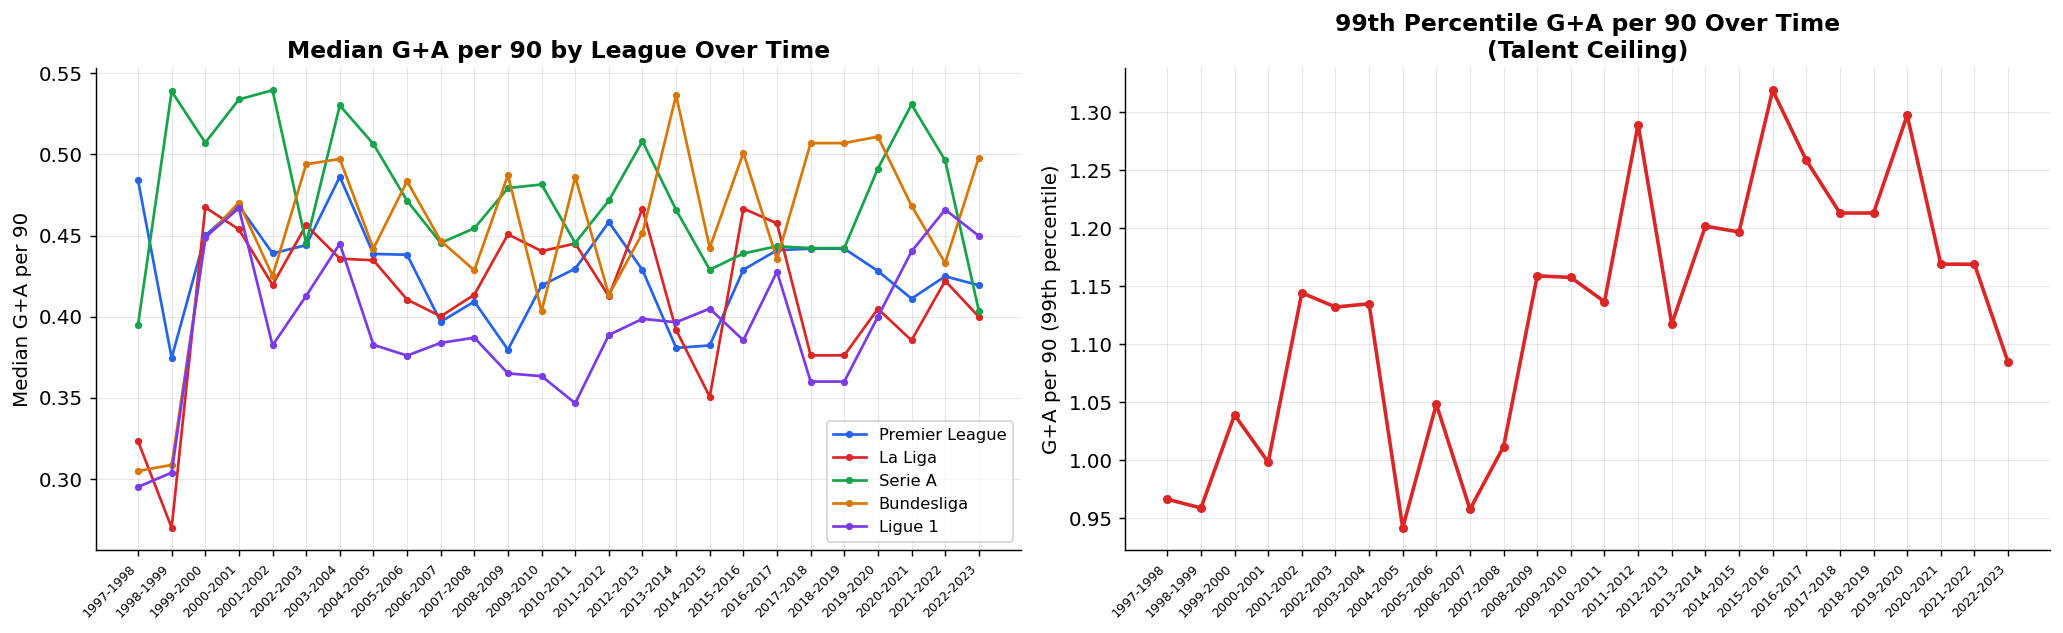

In [14]:
# League-level trends
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

league_season = (qf[qf['league'].isin(LEAGUES)]
                 .groupby(['season','league'])
                 .agg(median_ga_90=('ga_per_90','median'))
                 .reset_index())

for i, league in enumerate(LEAGUES):
    ld = league_season[league_season['league'] == league]
    axes[0].plot(ld['season'], ld['median_ga_90'],
                 marker='o', markersize=3, label=league,
                 color=PALETTE[i], linewidth=1.5)

axes[0].set_title('Median G+A per 90 by League Over Time')
axes[0].set_xticklabels(
    league_season['season'].unique(), rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Median G+A per 90')
axes[0].legend(fontsize=9)

# Top 1% G+A per 90 by season (talent ceiling)
top1pct = (qf.groupby('season')['ga_per_90']
             .quantile(0.99)
             .reset_index()
             .rename(columns={'ga_per_90': 'p99'}))
axes[1].plot(top1pct['season'], top1pct['p99'],
             marker='o', markersize=4, color='#DC2626', linewidth=2)
axes[1].set_title('99th Percentile G+A per 90 Over Time\n(Talent Ceiling)')
axes[1].set_xticklabels(top1pct['season'], rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('G+A per 90 (99th percentile)')

plt.tight_layout()
plt.savefig('fig09_league_trends.png', bbox_inches='tight')
plt.show()

---
## 8. Nationality Diversity: The Talent Pool Proxy

One of the inputs to the Full House Model is the talent pool —
the global pool from which each league draws its players.
Nationality diversity of the player pool is a direct proxy for
how globalised each league became over time.

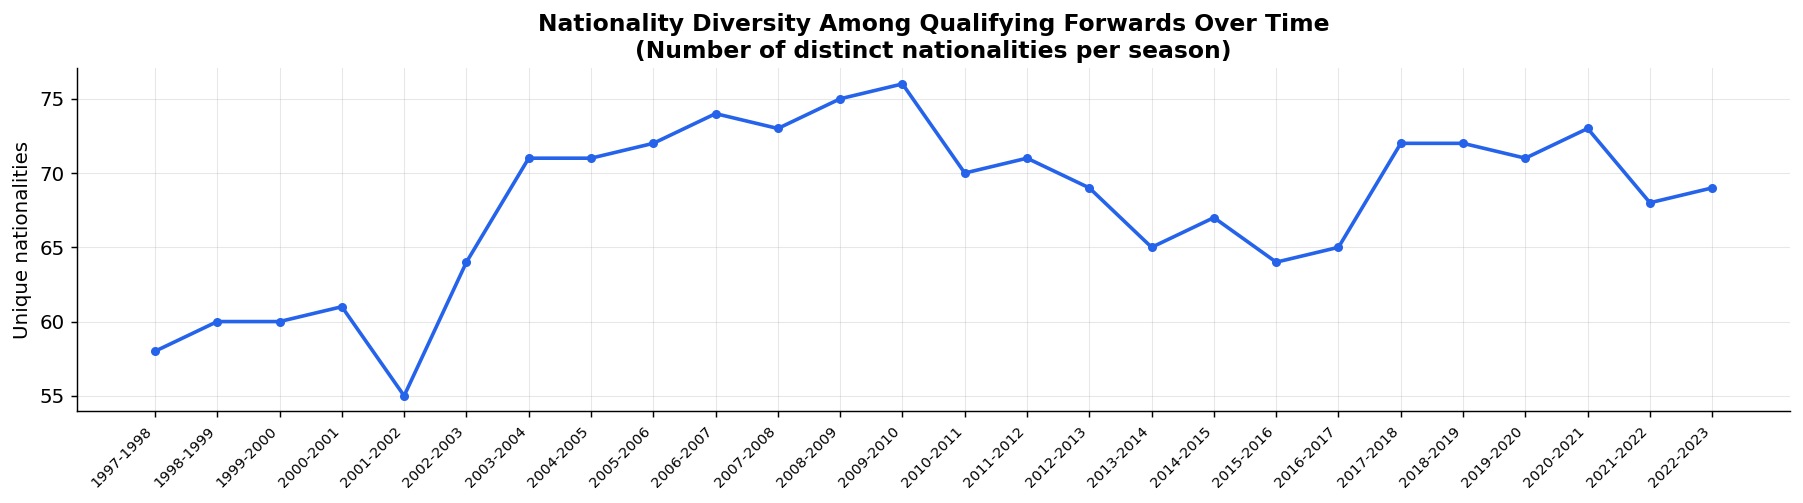

In [15]:
# Unique nationalities per season
nat_diversity = qf.groupby('season')['nationality'].nunique().reset_index()
nat_diversity.columns = ['season', 'unique_nationalities']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(nat_diversity['season'], nat_diversity['unique_nationalities'],
        marker='o', markersize=4, color='#2563EB', linewidth=2)
ax.set_title('Nationality Diversity Among Qualifying Forwards Over Time\n'
             '(Number of distinct nationalities per season)')
ax.set_xticklabels(nat_diversity['season'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Unique nationalities')
plt.tight_layout()
plt.savefig('fig10_nationality_diversity.png', bbox_inches='tight')
plt.show()

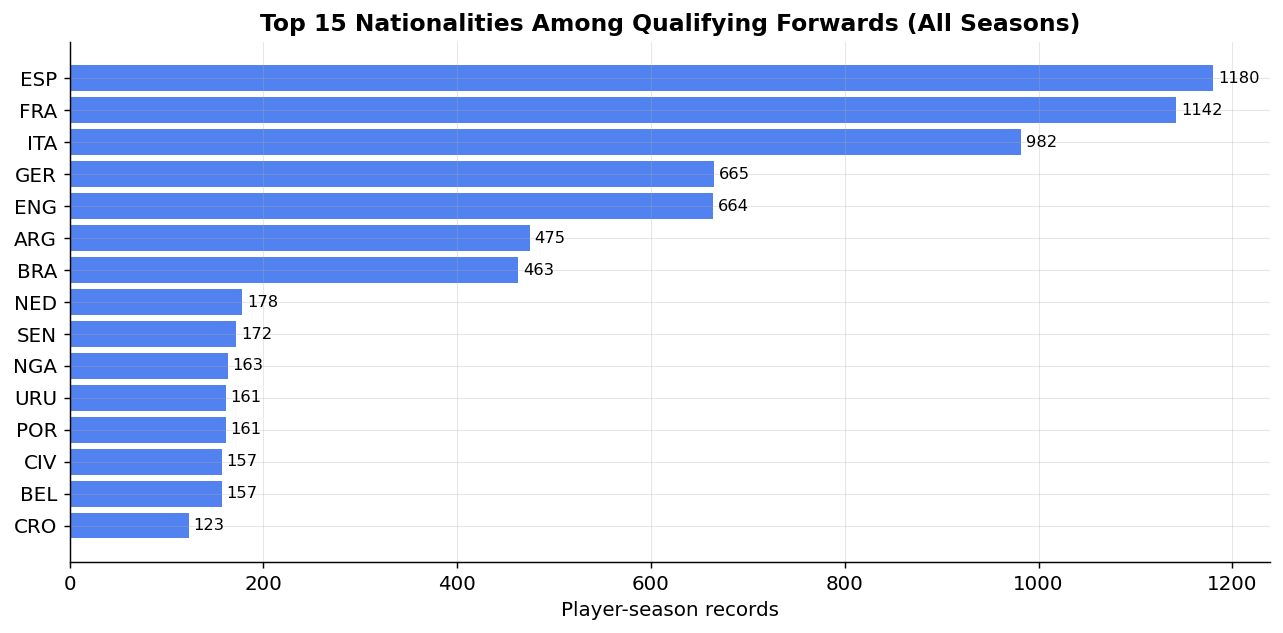

In [16]:
# Top nationalities across all seasons
top_nat = qf['nationality'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_nat.index[::-1], top_nat.values[::-1], color='#2563EB', alpha=0.8)
ax.set_title('Top 15 Nationalities Among Qualifying Forwards (All Seasons)')
ax.set_xlabel('Player-season records')
for i, (val, label) in enumerate(zip(top_nat.values[::-1],
                                      top_nat.index[::-1])):
    ax.text(val + 5, i, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig11_top_nationalities.png', bbox_inches='tight')
plt.show()

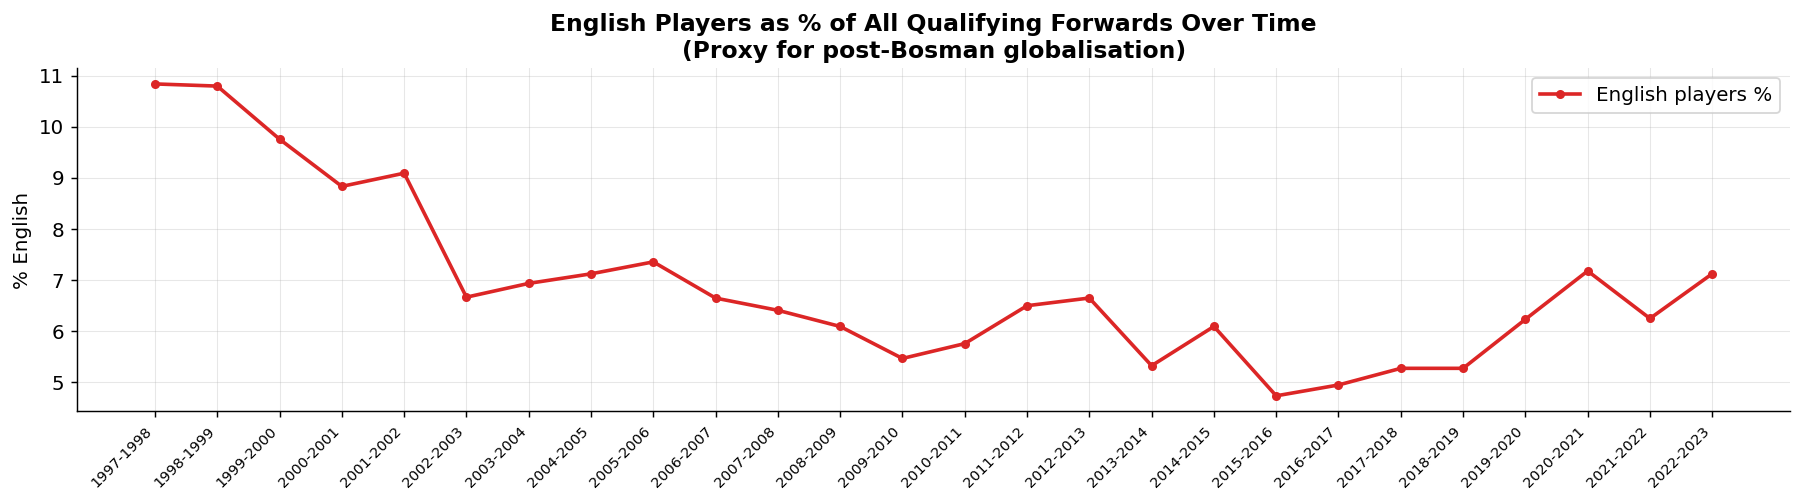

English players as % of qualifying forwards, by season:
   season   eng_pct
1997-1998 10.835913
1998-1999 10.793651
1999-2000  9.756098
2000-2001  8.832808
2001-2002  9.090909
2002-2003  6.666667
2003-2004  6.936416
2004-2005  7.123288
2005-2006  7.356948
2006-2007  6.648936
2007-2008  6.410256
2008-2009  6.094183
2009-2010  5.468750
2010-2011  5.759162
2011-2012  6.500000
2012-2013  6.650246
2013-2014  5.326877
2014-2015  6.094808
2015-2016  4.738155
2016-2017  4.950495
2017-2018  5.275779
2018-2019  5.275779
2019-2020  6.233766
2020-2021  7.179487
2021-2022  6.250000
2022-2023  7.125307


In [17]:
# English players as proportion of qualifying forwards — Bosman effect
eng_prop = (qf.groupby('season')
              .apply(lambda x: (x['nationality'] == 'ENG').mean() * 100)
              .reset_index())
eng_prop.columns = ['season', 'eng_pct']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(eng_prop['season'], eng_prop['eng_pct'],
        marker='o', markersize=4, color='#DC2626', linewidth=2,
        label='English players %')
ax.set_title('English Players as % of All Qualifying Forwards Over Time\n'
             '(Proxy for post-Bosman globalisation)')
ax.set_xticklabels(eng_prop['season'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('% English')
ax.legend()
plt.tight_layout()
plt.savefig('fig12_english_player_proportion.png', bbox_inches='tight')
plt.show()

print("English players as % of qualifying forwards, by season:")
print(eng_prop.to_string(index=False))

**Observation:** The decline in English player representation across
all five leagues reflects the Bosman ruling (1995) and subsequent
globalisation of European football. This is the structural driver
of talent pool expansion in the Full House Model — a forward dominating
a more international league faces a deeper talent pool and earns a
higher latent talent score.

---
## 9. League Depth: Qualifying Forwards per League per Season

The Full House Model requires a stable n per season per league.
Thin seasons destabilise the interpolated CDF.

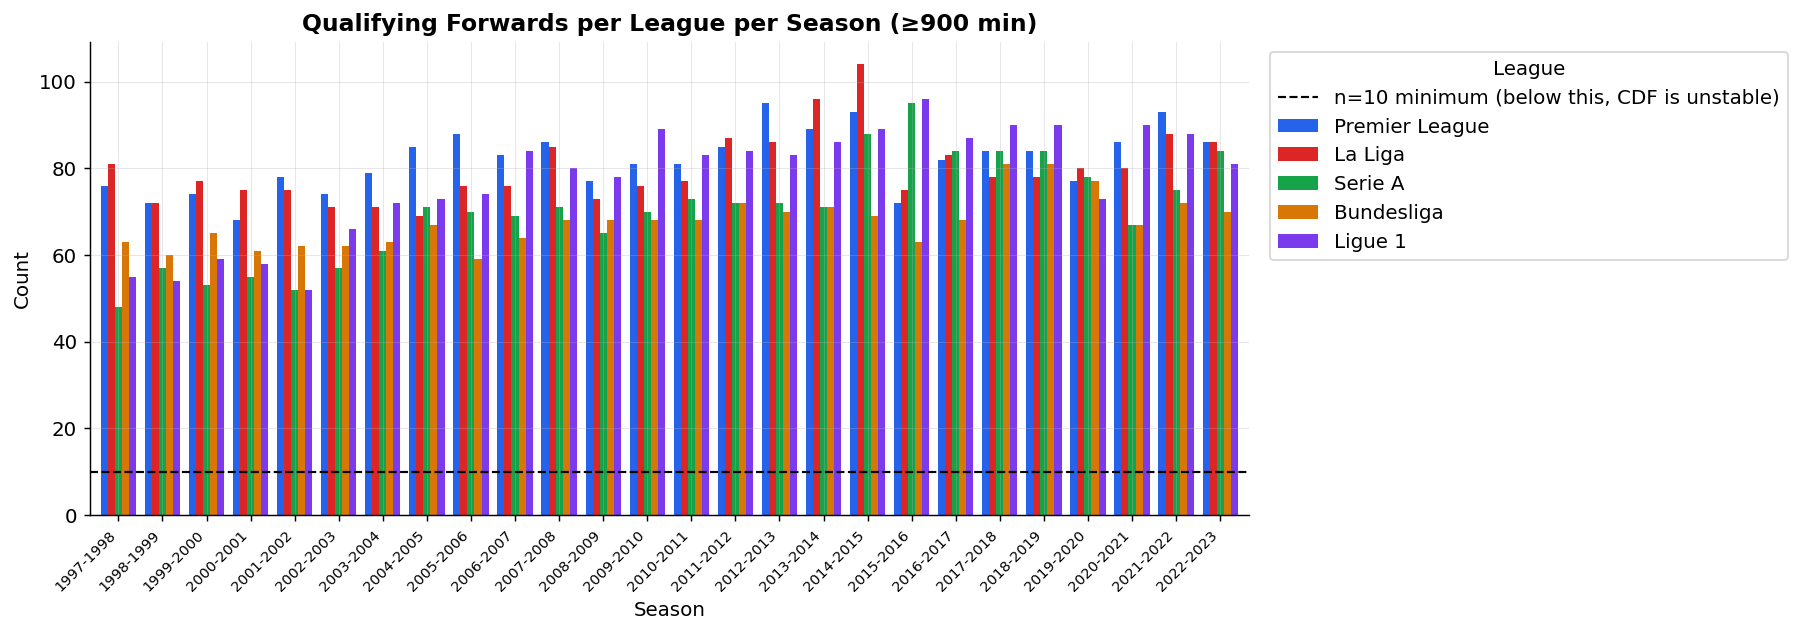


Minimum qualifying forwards in any single league-season:
league
Premier League    68
La Liga           69
Serie A           48
Bundesliga        59
Ligue 1           52

Seasons with fewer than 10 qualifying forwards in any league:
None — all league-seasons have ≥10 forwards


In [18]:
depth = (qf[qf['league'].isin(LEAGUES)]
         .groupby(['season','league'])
         .size()
         .unstack(fill_value=0)
         .reindex(columns=LEAGUES))

fig, ax = plt.subplots(figsize=(14, 5))
depth.plot(kind='bar', ax=ax, color=PALETTE, width=0.8)
ax.axhline(10, color='black', linestyle='--', linewidth=1.2,
           label='n=10 minimum (below this, CDF is unstable)')
ax.set_title(f'Qualifying Forwards per League per Season (≥{MIN_MINUTES} min)')
ax.set_xlabel('Season')
ax.set_ylabel('Count')
ax.set_xticklabels(depth.index, rotation=45, ha='right', fontsize=8)
ax.legend(title='League', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig13_depth_per_league.png', bbox_inches='tight')
plt.show()

print("\nMinimum qualifying forwards in any single league-season:")
print(depth.min().to_string())
print("\nSeasons with fewer than 10 qualifying forwards in any league:")
thin = (depth < 10).any(axis=1)
print(depth[thin].to_string() if thin.any() else "None — all league-seasons have ≥10 forwards")

---
## 10. Known Shortcomings Summary

A plain-language summary of every data limitation identified in
this analysis.

In [19]:
shortcomings = """
SHORTCOMING 1 — Two seasons missing entirely
  1995-96 and 1996-97 are absent. FBref's HTML structure for those pages
  differs from all subsequent seasons and the parser could not locate the
  stats table. These seasons can be recovered with a custom parser but
  have not been yet. The dataset therefore covers 26 of the intended 28 seasons.

SHORTCOMING 2 — Assists severely incomplete before 2000
  In 1997-98 and 1998-99, fewer than 20% of qualifying forwards have any
  assists recorded. The problem is concentrated in La Liga, Serie A, Bundesliga,
  and Ligue 1 — the EPL has reasonable coverage throughout. Using G+A as the
  metric for these seasons will systematically understate non-EPL players.
  Recommendation: use goals only as the metric for pre-2000 seasons.

SHORTCOMING 3 — Mid-season transfers cause double-counting
  Players who transferred between clubs mid-season appear twice in the data —
  once per club. This inflates forward counts and splits their stats across
  two rows. These must be collapsed to a single row (summed minutes, goals,
  assists) before modeling.

SHORTCOMING 4 — Small n per league per season
  After the 900-minute filter, each league has roughly 15-25 qualifying
  forwards per season. The original Eck et al. paper works with ~100+
  full-time batters per season in baseball. This smaller sample size
  makes the Scholz tail extrapolation less stable and increases sensitivity
  to individual outlier seasons.

SHORTCOMING 5 — Position definition is ambiguous
  FBref's position codes (FW, FW,MF, MF,FW) do not always reflect a
  player's functional role. A false nine or an inverted winger may be
  coded as MF rather than FW. The position taxonomy also evolved over
  the 26-season window as tactical systems changed.

SHORTCOMING 6 — G+A as the sole metric
  Goals + assists per 90 ignores defensive contribution, pressing,
  chance creation quality, and shot difficulty. There is no WAR-equivalent
  for football. For the purposes of the Full House Model this is acceptable
  as a first pass, but it means era-adjustment corrects for talent pool
  depth, not for tactical system differences across eras.

SHORTCOMING 7 — League quality is not yet weighted
  This dataset treats all five leagues as equivalent talent pools.
  The Ballon d'Or weighting (league quality index) has been scraped
  separately and is ready to merge — but that merge has not been done yet.
  Until it is, the Full House Model cannot distinguish a forward dominating
  peak Serie A from one dominating bottom-half Ligue 1.
"""
print(shortcomings)


SHORTCOMING 1 — Two seasons missing entirely
  1995-96 and 1996-97 are absent. FBref's HTML structure for those pages
  differs from all subsequent seasons and the parser could not locate the
  stats table. These seasons can be recovered with a custom parser but
  have not been yet. The dataset therefore covers 26 of the intended 28 seasons.

SHORTCOMING 2 — Assists severely incomplete before 2000
  In 1997-98 and 1998-99, fewer than 20% of qualifying forwards have any
  assists recorded. The problem is concentrated in La Liga, Serie A, Bundesliga,
  and Ligue 1 — the EPL has reasonable coverage throughout. Using G+A as the
  metric for these seasons will systematically understate non-EPL players.
  Recommendation: use goals only as the metric for pre-2000 seasons.

SHORTCOMING 3 — Mid-season transfers cause double-counting
  Players who transferred between clubs mid-season appear twice in the data —
  once per club. This inflates forward counts and splits their stats across
  two row

---
## 11. Immediate Next Steps

Before the Full House Model can be applied, three things must happen
in the pipeline:

1. **Collapse mid-season transfer duplicates** — sum stats across clubs
   for the same player in the same season.

2. **Decide the assist handling rule** — either goals-only for pre-2000
   or a split methodology with explicit documentation of which seasons
   use which metric.

3. **Merge the Ballon d'Or league quality weights** — the weights are
   already computed in `data/raw/ballon_dor/ballon_dor_winners.csv`
   and need to be joined to the player stats on `season × league`.

Once these three steps are done, the dataset is ready for the Full House
Model pipeline.

In [20]:
print("=== DATASET SNAPSHOT ===")
print(f"Seasons            : {df['season'].nunique()} ({df['season'].min()} → {df['season'].max()})")
print(f"Total records      : {len(df):,}")
print(f"Qualifying forwards: {len(qf):,}  (≥{MIN_MINUTES} min, FW/FW,MF/MF,FW positions)")
print(f"Unique players     : {qf['player'].nunique():,}")
print(f"Unique nationalities: {qf['nationality'].nunique()}")
print(f"Leagues            : {', '.join(LEAGUES)}")
print("Missing seasons    : 1995-96, 1996-97")
print("Assists fully clean: from ~2007-08 onwards")
print("Ready for modeling : NO — 3 pipeline steps remaining (see Section 11)")

=== DATASET SNAPSHOT ===
Seasons            : 26 (1997-1998 → 2022-2023)
Total records      : 69,330
Qualifying forwards: 9,802  (≥900 min, FW/FW,MF/MF,FW positions)
Unique players     : 2,713
Unique nationalities: 124
Leagues            : Premier League, La Liga, Serie A, Bundesliga, Ligue 1
Missing seasons    : 1995-96, 1996-97
Assists fully clean: from ~2007-08 onwards
Ready for modeling : NO — 3 pipeline steps remaining (see Section 11)
